In [1]:
# IMPORT LIBRARIES

import sys, os, glob, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc as sk_auc
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

# ── CONFIG ──────────────────────────────────────────────────────────────────
CSV_FOLDER   = './MachineLearningCVE'  
LABEL_COL    = 'Label'
N_FOLDS      = 10
TEST_SIZE    = 0.30        
RANDOM_STATE = 42
OUTPUT_DIR   = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

import sklearn
print(f'Scikit-learn : {sklearn.__version__}')
print(f'LightGBM     : {lgb.__version__}')
print(f'Pandas       : {pd.__version__}')

Scikit-learn : 1.8.0
LightGBM     : 4.6.0
Pandas       : 3.0.3


In [2]:
# LOAD DATA
csv_files = sorted(glob.glob(os.path.join(CSV_FOLDER, '*.csv')))
if not csv_files:
    raise FileNotFoundError(f'No CSV files in {CSV_FOLDER}')
dfs = []
for f in csv_files:
    print(f'  Loading {os.path.basename(f)}')
    dfs.append(pd.read_csv(f, low_memory=False))
df = pd.concat(dfs, ignore_index=True)
print(f'Total rows: {len(df):,}')
del dfs; gc.collect()

  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loading Monday-WorkingHours.pcap_ISCX.csv
  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Loading Tuesday-WorkingHours.pcap_ISCX.csv
  Loading Wednesday-workingHours.pcap_ISCX.csv
Total rows: 2,830,743


30

In [3]:
df.columns = df.columns.str.strip()

# Drop irrelevant ID columns
drop_cols = [c for c in ['Flow ID','Source IP','Destination IP','Timestamp',
                          'Src IP','Dst IP','src_ip','dst_ip'] if c in df.columns]
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)

# Replace infinities with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop COLUMNS with >50% missing (axis=1 is correct here for columns)
df.dropna(axis=1, thresh=int(len(df) * 0.5), inplace=True)  
df.dropna(axis=0, inplace=True)                               

# Deduplicate BEFORE the train/test split to prevent leakage
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Dedup removed {before - len(df):,} rows')
print(f'Shape after dedup: {df.shape}')

Dedup removed 307,078 rows
Shape after dedup: (2520798, 79)


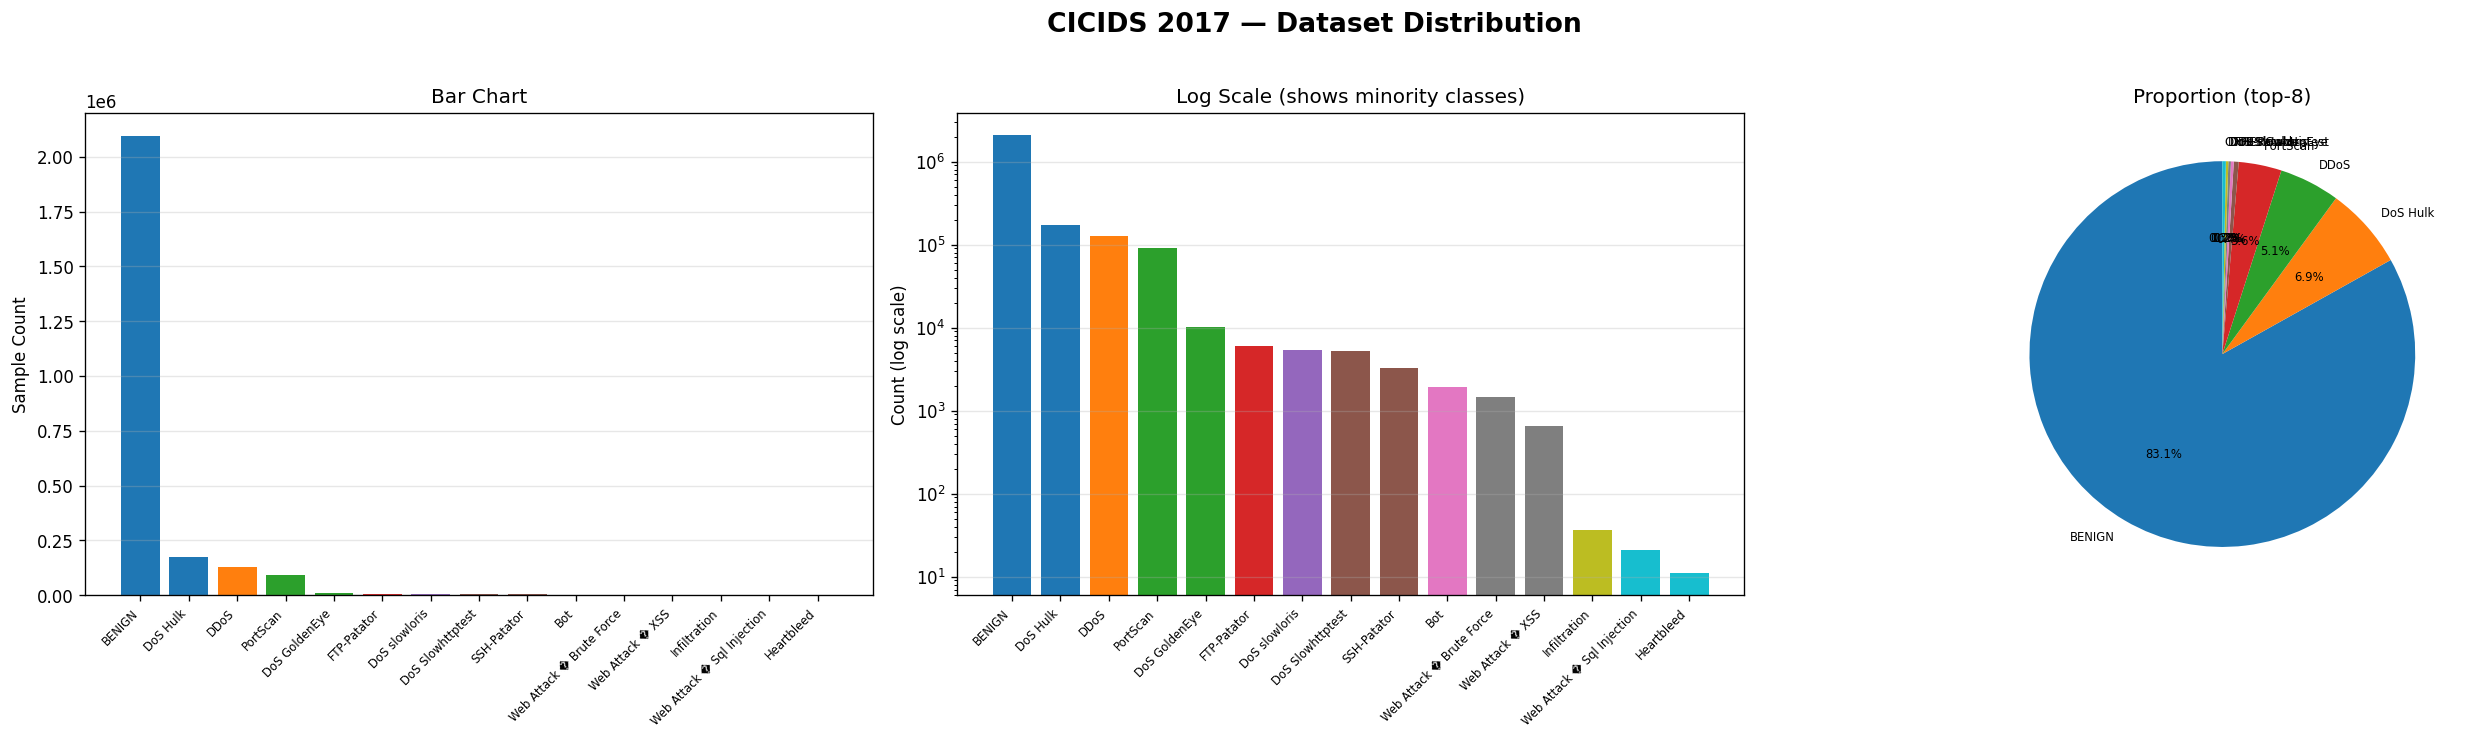

Saved: dataset_distribution.png


In [4]:
class_counts    = df[LABEL_COL].value_counts()
class_names_raw = class_counts.index.tolist()
n_classes_raw   = len(class_names_raw)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('CICIDS 2017 — Dataset Distribution', fontsize=16, fontweight='bold', y=1.02)
colors = plt.cm.tab10(np.linspace(0, 1, n_classes_raw))

axes[0].bar(range(n_classes_raw), class_counts.values, color=colors)
axes[0].set_xticks(range(n_classes_raw))
axes[0].set_xticklabels(class_names_raw, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Sample Count'); axes[0].set_title('Bar Chart'); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(n_classes_raw), class_counts.values, color=colors)
axes[1].set_xticks(range(n_classes_raw))
axes[1].set_xticklabels(class_names_raw, rotation=45, ha='right', fontsize=7)
axes[1].set_yscale('log'); axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Log Scale (shows minority classes)'); axes[1].grid(axis='y', alpha=0.3)

top_n    = min(8, n_classes_raw)
pie_data = (class_counts if n_classes_raw <= top_n
            else pd.concat([class_counts.head(top_n),
                            pd.Series({'OTHER': class_counts.iloc[top_n:].sum()})]))
axes[2].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=plt.cm.tab10(np.linspace(0,1,len(pie_data))),
            startangle=90, textprops={'fontsize':7})
axes[2].set_title(f'Proportion (top-{top_n})', fontsize=12)

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dataset_distribution.png')

In [5]:
# ENCODE & SCALE

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df[LABEL_COL].astype(str))
class_names = le.classes_
n_classes   = len(class_names)
print(f'Classes ({n_classes}):')
for i, n in enumerate(class_names): print(f'  {i:2d}: {n}')

X = df.drop(columns=[LABEL_COL, 'label_enc']).select_dtypes(include=[np.number])
y = df['label_enc']

# 70/30 split as specified in the paper
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

scaler  = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

del df; gc.collect()
print('Encoding & scaling done ✔')

Classes (15):
   0: BENIGN
   1: Bot
   2: DDoS
   3: DoS GoldenEye
   4: DoS Hulk
   5: DoS Slowhttptest
   6: DoS slowloris
   7: FTP-Patator
   8: Heartbleed
   9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack � Brute Force
  13: Web Attack � Sql Injection
  14: Web Attack � XSS
Train: (1764558, 78) | Test: (756240, 78)
Encoding & scaling done ✔


In [ ]:
# LightGBM base learner 
# We use is_unbalance=True (native) and remove class_weight to avoid conflict.
lgbm_params = dict(
    objective         = 'multiclass',
    metric            = 'multi_logloss',
    num_class         = n_classes,
    n_estimators      = 100,          
    learning_rate     = 0.05,
    max_depth         = 8,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    is_unbalance      = True,        
    device            = 'cpu',
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbose           = -1,
)

# Bagging + DT (Random Subspace) 

n_features = X_train.shape[1]
bagging_params = dict(
    estimator   = DecisionTreeClassifier(
                      criterion     = 'gini',
                      max_depth     = 10,
                      min_samples_split = 20,
                      min_samples_leaf  = 10,
                      class_weight  = 'balanced',  
                      random_state  = RANDOM_STATE
                  ),
    n_estimators = 50,
    max_samples  = 0.8,
    max_features = max(1, int(np.sqrt(n_features))), 
    bootstrap    = True,
    n_jobs       = -1,
    random_state = RANDOM_STATE,
)

print(f'LightGBM params:      n_estimators={lgbm_params["n_estimators"]}, is_unbalance=True')
print(f'Bagging max_features: {bagging_params["max_features"]} (sqrt of {n_features})')
print('Model definitions OK ✔')

LightGBM params:      n_estimators=100, is_unbalance=True
Bagging max_features: 8 (sqrt of 78)
Model definitions OK ✔


In [7]:
# CROSS-VALIDATION
print(f'Running {N_FOLDS}-Fold CV...\n')
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

Xa  = X_train.values
ya  = y_train.values
Xta = X_test.values

oof_lgbm    = np.zeros((len(Xa), n_classes))
oof_bagging = np.zeros((len(Xa), n_classes))



test_lgbm_accum    = np.zeros((len(Xta), n_classes))
test_bagging_accum = np.zeros((len(Xta), n_classes))

fold_results   = []   
fold_loss_curves = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(Xa, ya), 1):
    print(f'  Fold {fold}/{N_FOLDS}', end='')
    Xtr, Xval = Xa[tr_idx], Xa[val_idx]
    ytr, yval = ya[tr_idx], ya[val_idx]

    # LightGBM 
    lgbm_fold = lgb.LGBMClassifier(**lgbm_params)
    evals = {}
    lgbm_fold.fit(
        Xtr, ytr,
        eval_set       = [(Xtr, ytr), (Xval, yval)],
        eval_names     = ['train', 'eval'],
        callbacks      = [
            lgb.record_evaluation(evals),
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    oof_lgbm[val_idx]   = lgbm_fold.predict_proba(Xval)
    test_lgbm_accum    += lgbm_fold.predict_proba(Xta) 

    train_loss = evals['train']['multi_logloss']
    val_loss   = evals['eval']['multi_logloss']
    best_iter  = lgbm_fold.best_iteration_
    fold_loss_curves.append({
        'fold': fold, 'train': train_loss, 'eval': val_loss, 'best': best_iter
    })
    print(f' | LGBM OK (best={best_iter})', end='')

    # Bagging + DT 
   
    bagging_fold = BaggingClassifier(**bagging_params)
    bagging_fold.fit(Xtr, ytr)
    oof_bagging[val_idx]   = bagging_fold.predict_proba(Xval)
    test_bagging_accum    += bagging_fold.predict_proba(Xta)
    print(' | Bagging OK')


    oof_val_pred_lgbm    = np.argmax(oof_lgbm[val_idx], axis=1)
    oof_val_pred_bagging = np.argmax(oof_bagging[val_idx], axis=1)

    fold_results.append({
        'fold'           : fold,
        'val_loss_lgbm'  : val_loss[best_iter - 1] if best_iter else val_loss[-1],
        'lgbm_acc'       : accuracy_score(yval, oof_val_pred_lgbm),
        'lgbm_f1'        : f1_score(yval, oof_val_pred_lgbm, average='weighted', zero_division=0),
        'bagging_acc'    : accuracy_score(yval, oof_val_pred_bagging),
        'bagging_f1'     : f1_score(yval, oof_val_pred_bagging, average='weighted', zero_division=0),
    })
    gc.collect()

# Average test predictions across all folds
test_lgbm_avg    = test_lgbm_accum    / N_FOLDS
test_bagging_avg = test_bagging_accum / N_FOLDS

print(f'\nOOF shapes: lgbm={oof_lgbm.shape}, bagging={oof_bagging.shape}')
print('Cross-validation complete ✔')

Running 10-Fold CV...

  Fold 1/10 | LGBM OK (best=100) | Bagging OK
  Fold 2/10 | LGBM OK (best=100) | Bagging OK
  Fold 3/10 | LGBM OK (best=100) | Bagging OK
  Fold 4/10 | LGBM OK (best=100) | Bagging OK
  Fold 5/10 | LGBM OK (best=100) | Bagging OK
  Fold 6/10 | LGBM OK (best=100) | Bagging OK
  Fold 7/10 | LGBM OK (best=100) | Bagging OK
  Fold 8/10 | LGBM OK (best=100) | Bagging OK
  Fold 9/10 | LGBM OK (best=100) | Bagging OK
  Fold 10/10 | LGBM OK (best=100) | Bagging OK

OOF shapes: lgbm=(1764558, 15), bagging=(1764558, 15)
Cross-validation complete ✔



=== Per-Fold OOF Metrics ===
      val_loss_lgbm  lgbm_acc  lgbm_f1  bagging_acc  bagging_f1
fold                                                           
1            0.0040    0.9989   0.9988       0.9538      0.9711
2            0.0060    0.9989   0.9989       0.9528      0.9702
3            0.0082    0.9987   0.9986       0.9541      0.9719
4            0.0048    0.9988   0.9988       0.9575      0.9744
5            0.0058    0.9987   0.9987       0.9556      0.9731
6            0.0053    0.9988   0.9988       0.9541      0.9720
7            0.0038    0.9989   0.9989       0.9456      0.9670
8            0.0044    0.9989   0.9989       0.9519      0.9705
9            0.0057    0.9988   0.9987       0.9556      0.9722
10           0.0062    0.9988   0.9988       0.9563      0.9730

★ BEST FOLD: Fold 7
val_loss_lgbm    0.0038
lgbm_acc         0.9989
lgbm_f1          0.9989
bagging_acc      0.9456
bagging_f1       0.9670


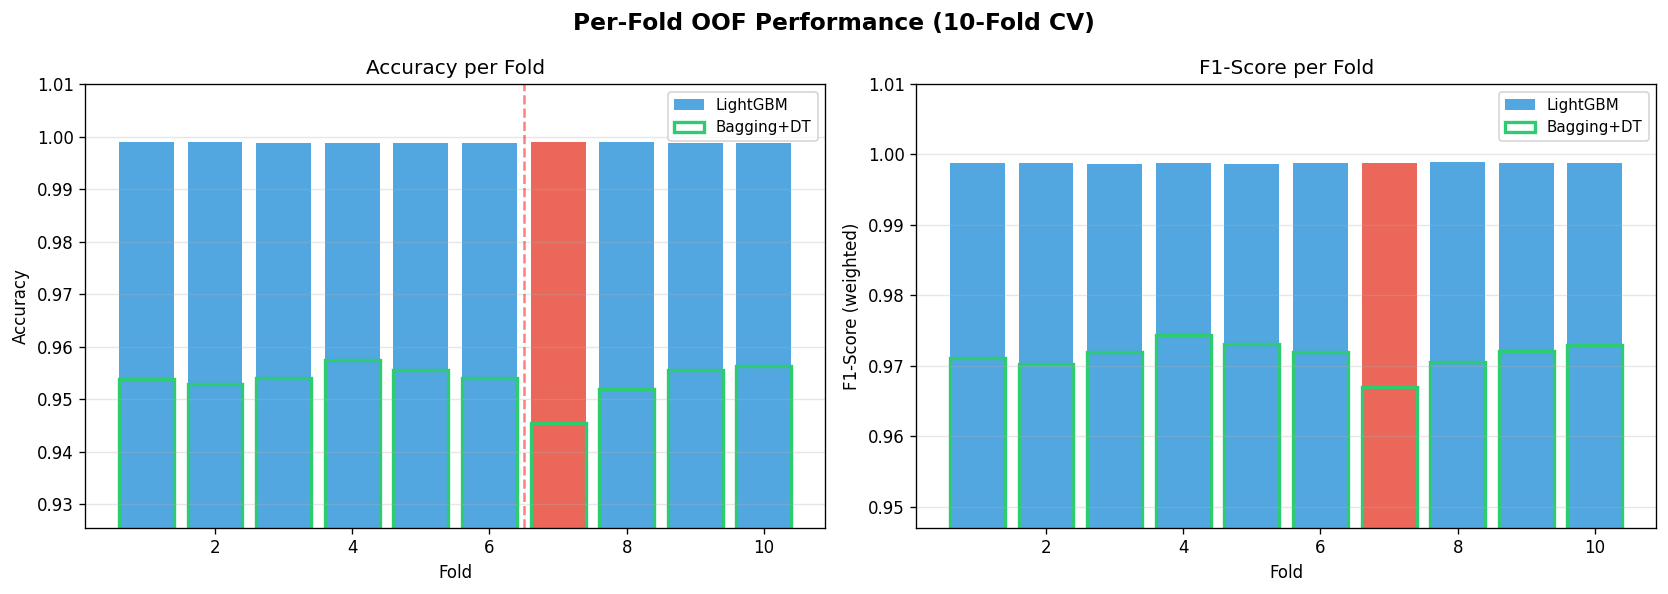

Saved: fold_performance.png


In [8]:
# Analyze fold results
fold_df = pd.DataFrame(fold_results)
fold_df = fold_df.set_index('fold')

# Best fold = lowest LightGBM validation log-loss
best_fold_idx = fold_df['val_loss_lgbm'].idxmin()

print('\n=== Per-Fold OOF Metrics ===')
print(fold_df.round(4).to_string())
print(f'\n★ BEST FOLD: Fold {best_fold_idx}')
print(fold_df.loc[best_fold_idx].round(4).to_string())

# Plot fold comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Fold OOF Performance (10-Fold CV)', fontsize=14, fontweight='bold')

folds = fold_df.index.tolist()
bar_colors = ['#e74c3c' if f == best_fold_idx else '#3498db' for f in folds]

# Accuracy
axes[0].bar(folds, fold_df['lgbm_acc'], color=bar_colors, alpha=0.85, label='LightGBM')
axes[0].bar(folds, fold_df['bagging_acc'], color='none',
            edgecolor='#2ecc71', linewidth=2, label='Bagging+DT')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy per Fold'); axes[0].legend(fontsize=9)
axes[0].set_ylim(fold_df[['lgbm_acc','bagging_acc']].min().min() - 0.02, 1.01)
axes[0].axvline(best_fold_idx - 0.5, color='red', linestyle='--', alpha=0.5, label=f'Best (Fold {best_fold_idx})')
axes[0].grid(axis='y', alpha=0.3)

# F1
axes[1].bar(folds, fold_df['lgbm_f1'], color=bar_colors, alpha=0.85, label='LightGBM')
axes[1].bar(folds, fold_df['bagging_f1'], color='none',
            edgecolor='#2ecc71', linewidth=2, label='Bagging+DT')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('F1-Score (weighted)')
axes[1].set_title('F1-Score per Fold'); axes[1].legend(fontsize=9)
axes[1].set_ylim(fold_df[['lgbm_f1','bagging_f1']].min().min() - 0.02, 1.01)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fold_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fold_performance.png')

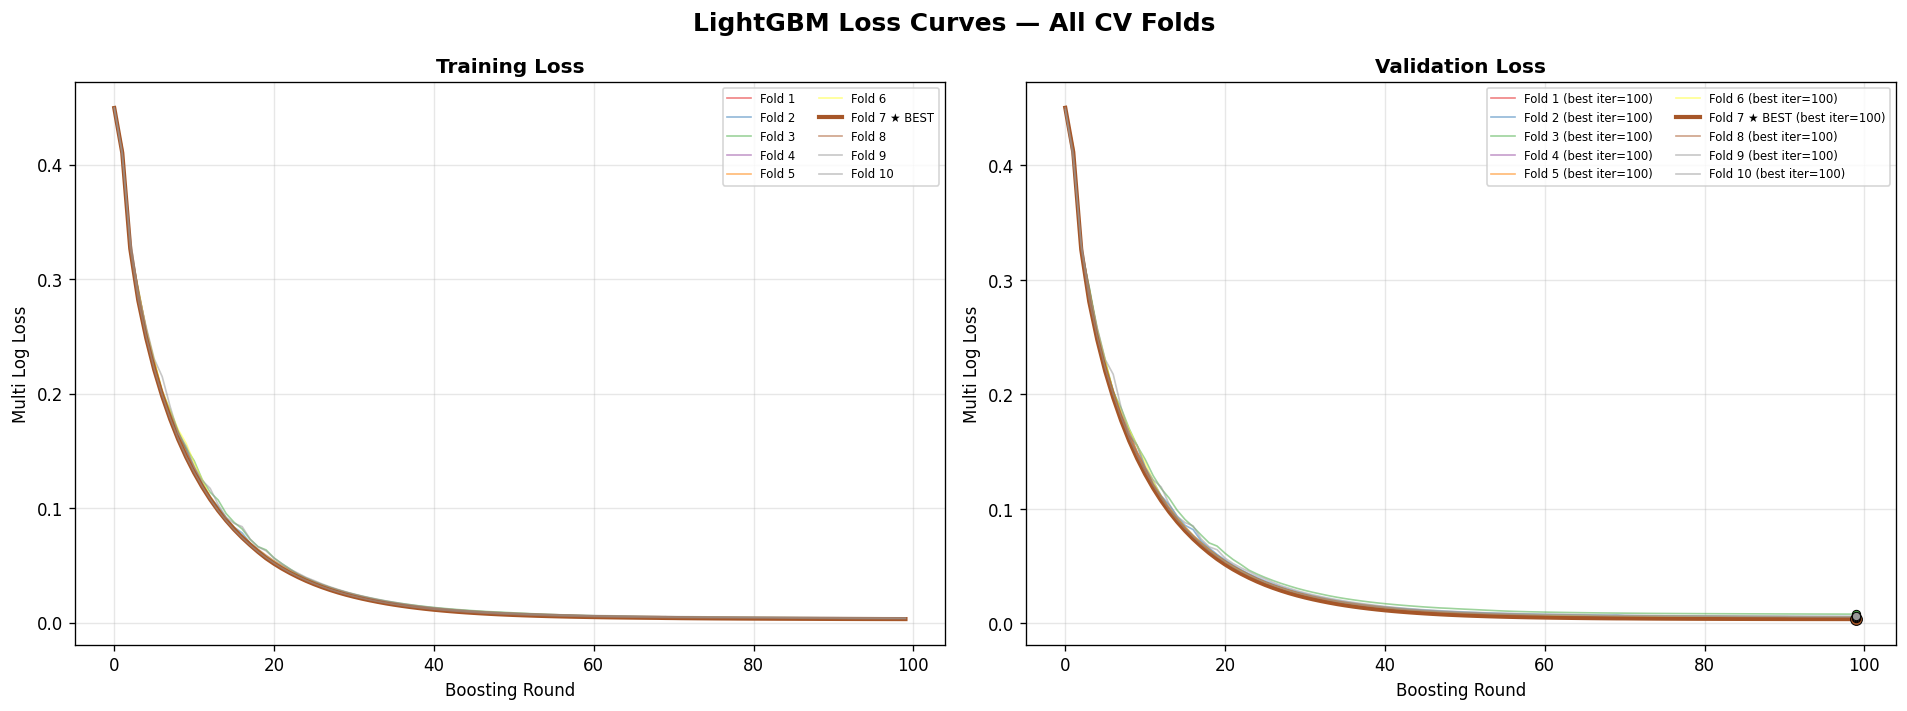

Saved: loss_curves.png


In [9]:
# Plot fold loss curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM Loss Curves — All CV Folds', fontsize=15, fontweight='bold')
colors_fold = plt.cm.Set1(np.linspace(0, 1, N_FOLDS))

for i, fc in enumerate(fold_loss_curves):
    is_best = fc['fold'] == best_fold_idx
    lw      = 2.5 if is_best else 1.0
    alpha   = 1.0 if is_best else 0.55
    label   = f"Fold {fc['fold']} ★ BEST" if is_best else f"Fold {fc['fold']}"

    axes[0].plot(fc['train'], color=colors_fold[i], alpha=alpha, lw=lw, label=label)
    axes[1].plot(fc['eval'],  color=colors_fold[i], alpha=alpha, lw=lw,
                 label=f"{label} (best iter={fc['best']})")

    best_i = fc['best'] - 1
    if 0 <= best_i < len(fc['eval']):
        axes[1].scatter(best_i, fc['eval'][best_i],
                        color=colors_fold[i], s=50 if is_best else 25,
                        zorder=5, edgecolors='black', linewidths=0.6)

for ax, title in zip(axes, ['Training Loss', 'Validation Loss']):
    ax.set_xlabel('Boosting Round'); ax.set_ylabel('Multi Log Loss')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: loss_curves.png')

In [10]:
# OOF predictions from all folds → meta-feature matrix
M_train = np.hstack([oof_lgbm, oof_bagging])
M_test  = np.hstack([test_lgbm_avg, test_bagging_avg])
print(f'Meta-feature matrix: Train {M_train.shape} | Test {M_test.shape}')

meta = LogisticRegression(
    max_iter     = 1000,
    random_state = RANDOM_STATE,
    class_weight = 'balanced',
    solver       = 'lbfgs',
    n_jobs       = -1,
)
meta.fit(M_train, ya)
print('Meta-learner trained ✔')

Meta-feature matrix: Train (1764558, 30) | Test (756240, 30)
Meta-learner trained ✔


In [ ]:
# Saving models and results
import joblib

SAVE_DIR = './saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save the last fold's models and the meta-learner, along with encoders and fold results
joblib.dump(meta,          f'{SAVE_DIR}/meta_learner.pkl')
joblib.dump(scaler,        f'{SAVE_DIR}/scaler.pkl')
joblib.dump(le,            f'{SAVE_DIR}/label_encoder.pkl')
joblib.dump(fold_results,  f'{SAVE_DIR}/fold_results.pkl')


print(f'✅ Models saved to {SAVE_DIR}/')

✅ Models saved to ./saved_model/


In [12]:
# FINAL EVALUATION ON TEST SET
y_pred     = meta.predict(M_test)
y_prob     = meta.predict_proba(M_test)

acc        = accuracy_score(y_test, y_pred)
prec       = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec        = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1         = f1_score(y_test, y_pred, average='weighted', zero_division=0)
ll         = log_loss(y_test, y_prob)
auc_score  = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print('=' * 50)
print('  STACKED ENSEMBLE — TEST SET METRICS')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc_score:.4f}')
print(f'  Log Loss  : {ll:.4f}')
print('=' * 50)

if acc > 0.99:
    print('\n⚠️  WARNING: Accuracy > 99%. Check for remaining data leakage,')
    print('   duplicate flows between train/test, or highly separable classes.')

  STACKED ENSEMBLE — TEST SET METRICS
  Accuracy  : 0.9671
  Precision : 0.9984
  Recall    : 0.9671
  F1-Score  : 0.9822
  AUC-ROC   : 0.9998
  Log Loss  : 0.1482


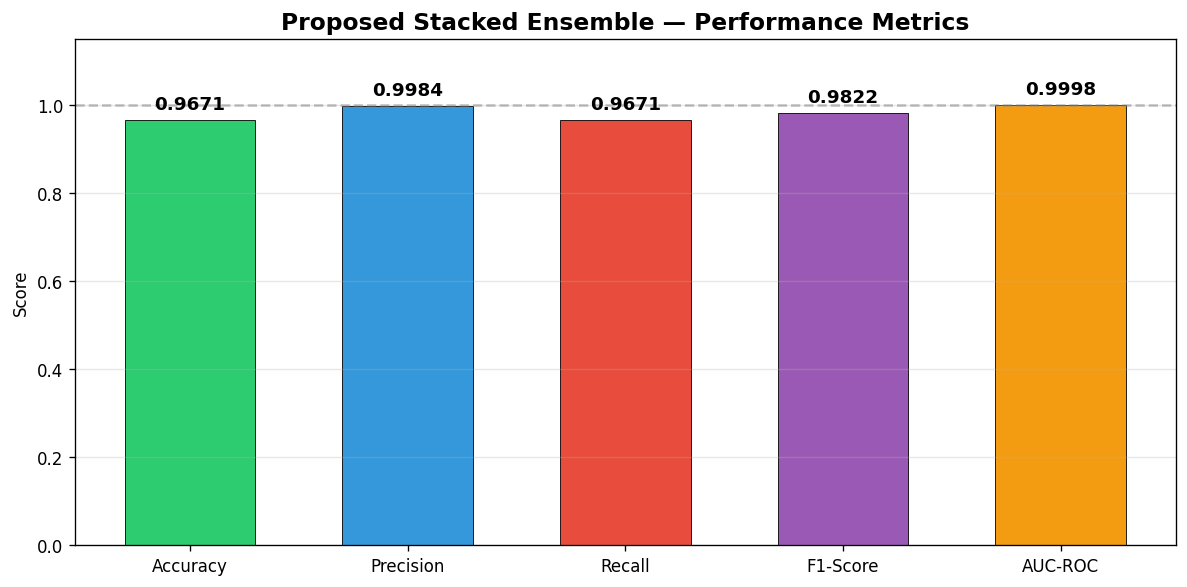

Saved: performance_metrics.png


In [13]:
# Plot test set performance metrics
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metric_vals  = [acc, prec, rec, f1, auc_score]
bar_colors   = ['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metric_names, metric_vals, color=bar_colors,
              width=0.6, edgecolor='black', linewidth=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title('Proposed Stacked Ensemble — Performance Metrics',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(y=1.0, color='gray', ls='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('performance_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: performance_metrics.png')

In [14]:
# Detailed classification report
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0, digits=4))

                            precision    recall  f1-score   support

                    BENIGN     1.0000    0.9610    0.9801    628518
                       Bot     0.3589    0.9949    0.5275       584
                      DDoS     0.9999    0.9999    0.9999     38404
             DoS GoldenEye     0.9955    0.9964    0.9960      3086
                  DoS Hulk     0.9989    0.9981    0.9985     51854
          DoS Slowhttptest     0.9215    0.9962    0.9574      1568
             DoS slowloris     0.9926    0.9901    0.9913      1616
               FTP-Patator     0.9994    0.9994    0.9994      1779
                Heartbleed     1.0000    0.6667    0.8000         3
              Infiltration     0.0005    0.9091    0.0010        11
                  PortScan     0.9894    0.9995    0.9944     27208
               SSH-Patator     0.9847    1.0000    0.9923       966
  Web Attack � Brute Force     0.8256    0.5261    0.6427       441
Web Attack � Sql Injection     0.0096    1.0000

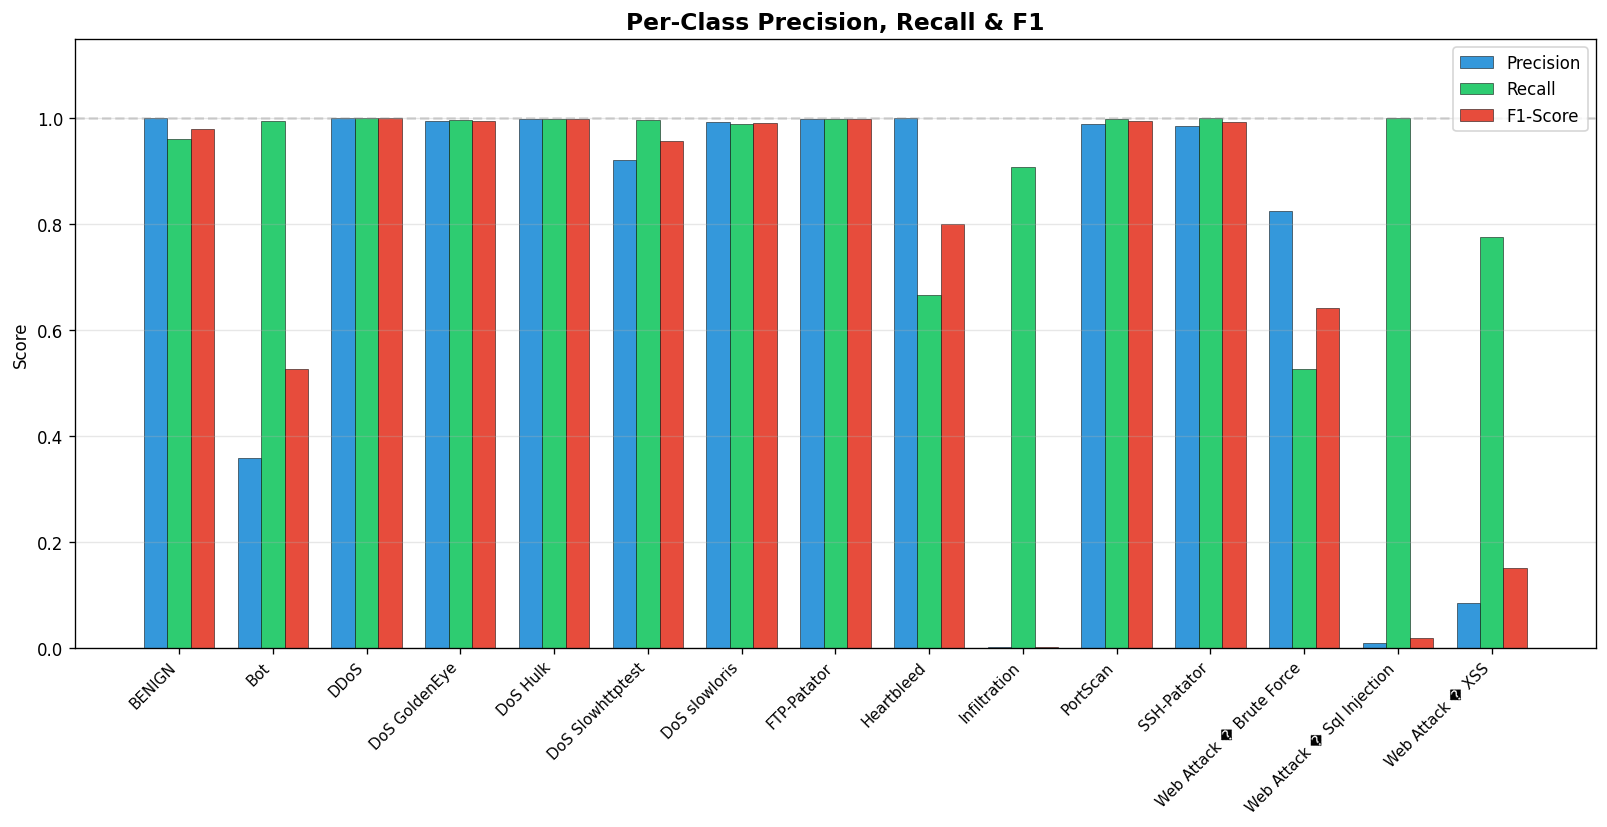

Saved: classification_report_graph.png


In [15]:
# Per-class precision, recall, F1-score
prec_p = precision_score(y_test, y_pred, average=None, zero_division=0)
rec_p  = recall_score(y_test, y_pred, average=None, zero_division=0)
f1_p   = f1_score(y_test, y_pred, average=None, zero_division=0)

x = np.arange(n_classes); w = 0.25
fig, ax = plt.subplots(figsize=(max(12, n_classes * 0.9), 7))
ax.bar(x - w, prec_p, w, label='Precision', color='#3498db', edgecolor='black', lw=0.3)
ax.bar(x,     rec_p,  w, label='Recall',    color='#2ecc71', edgecolor='black', lw=0.3)
ax.bar(x + w, f1_p,   w, label='F1-Score',  color='#e74c3c', edgecolor='black', lw=0.3)
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall & F1', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15); ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', ls='--', alpha=0.3)
plt.tight_layout()
plt.savefig('classification_report_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: classification_report_graph.png')

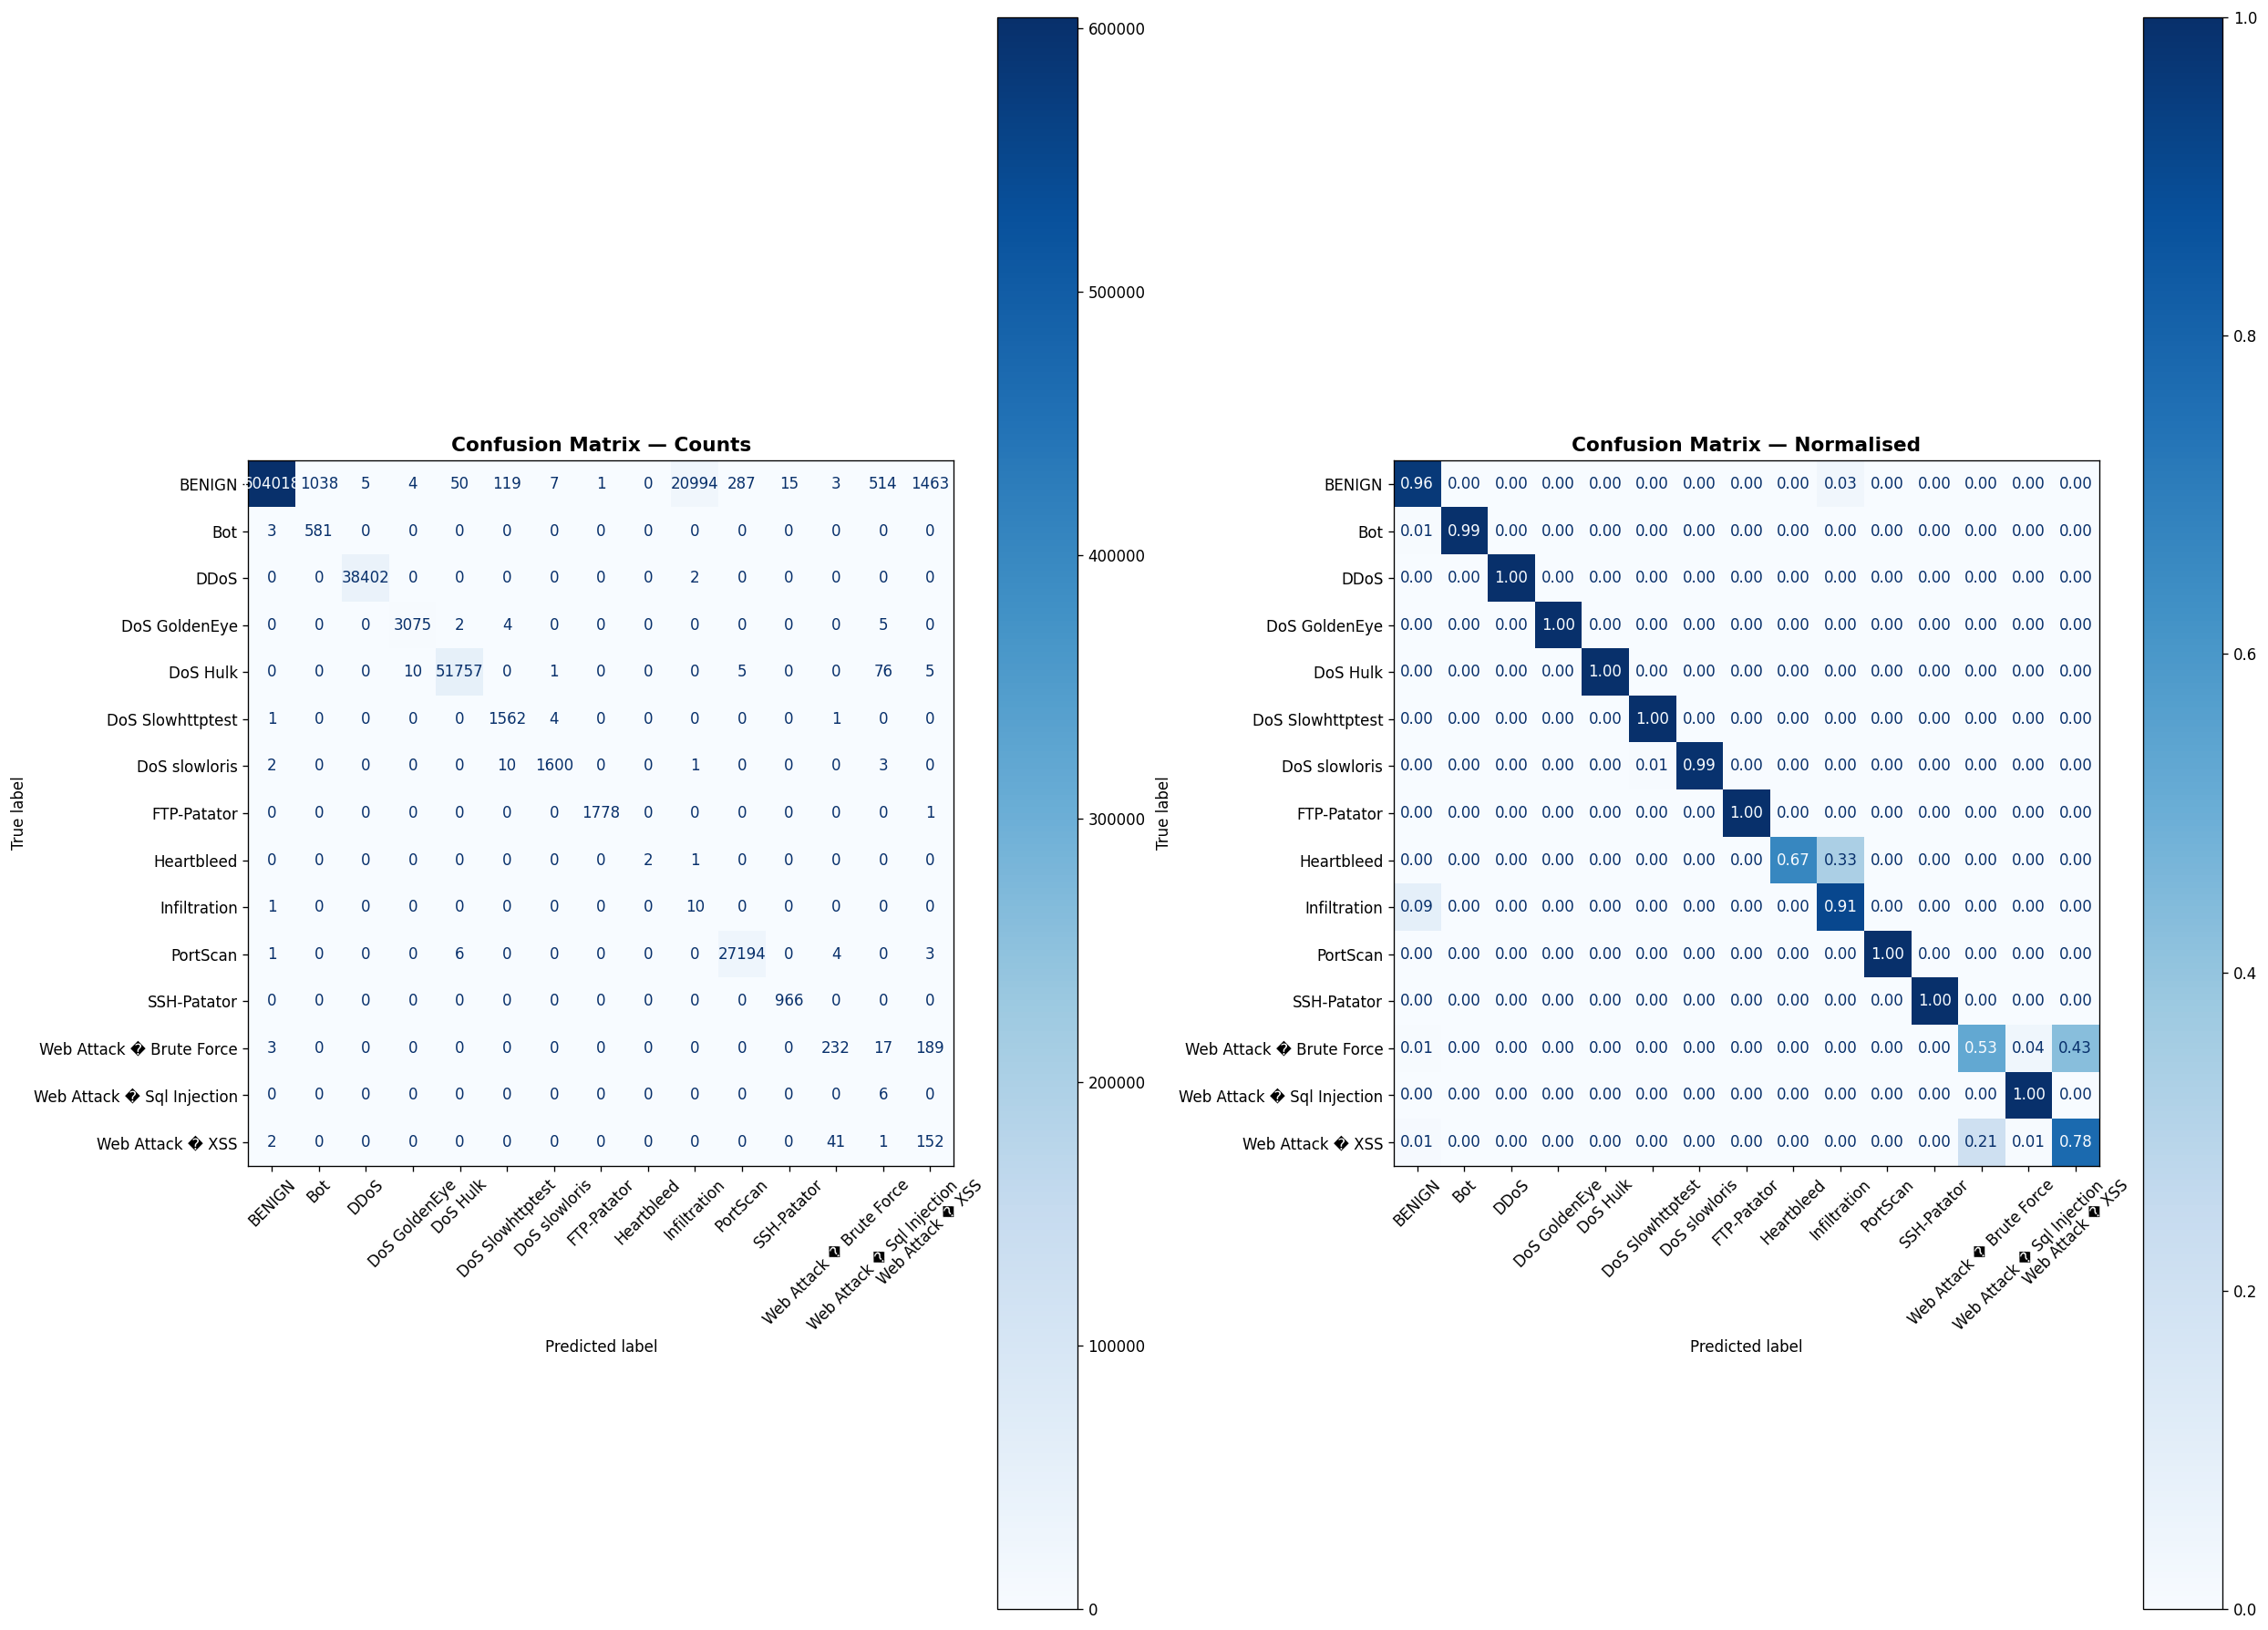

Saved: confusion_matrix.png


In [16]:
# Confusion Matrix (counts and normalized)
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(max(20, n_classes * 1.4), max(8, n_classes)))

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], cmap='Blues', colorbar=True, xticks_rotation=45, values_format='d')
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=axes[1], cmap='Blues', colorbar=True, xticks_rotation=45, values_format='.2f')
axes[1].set_title('Confusion Matrix — Normalised', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

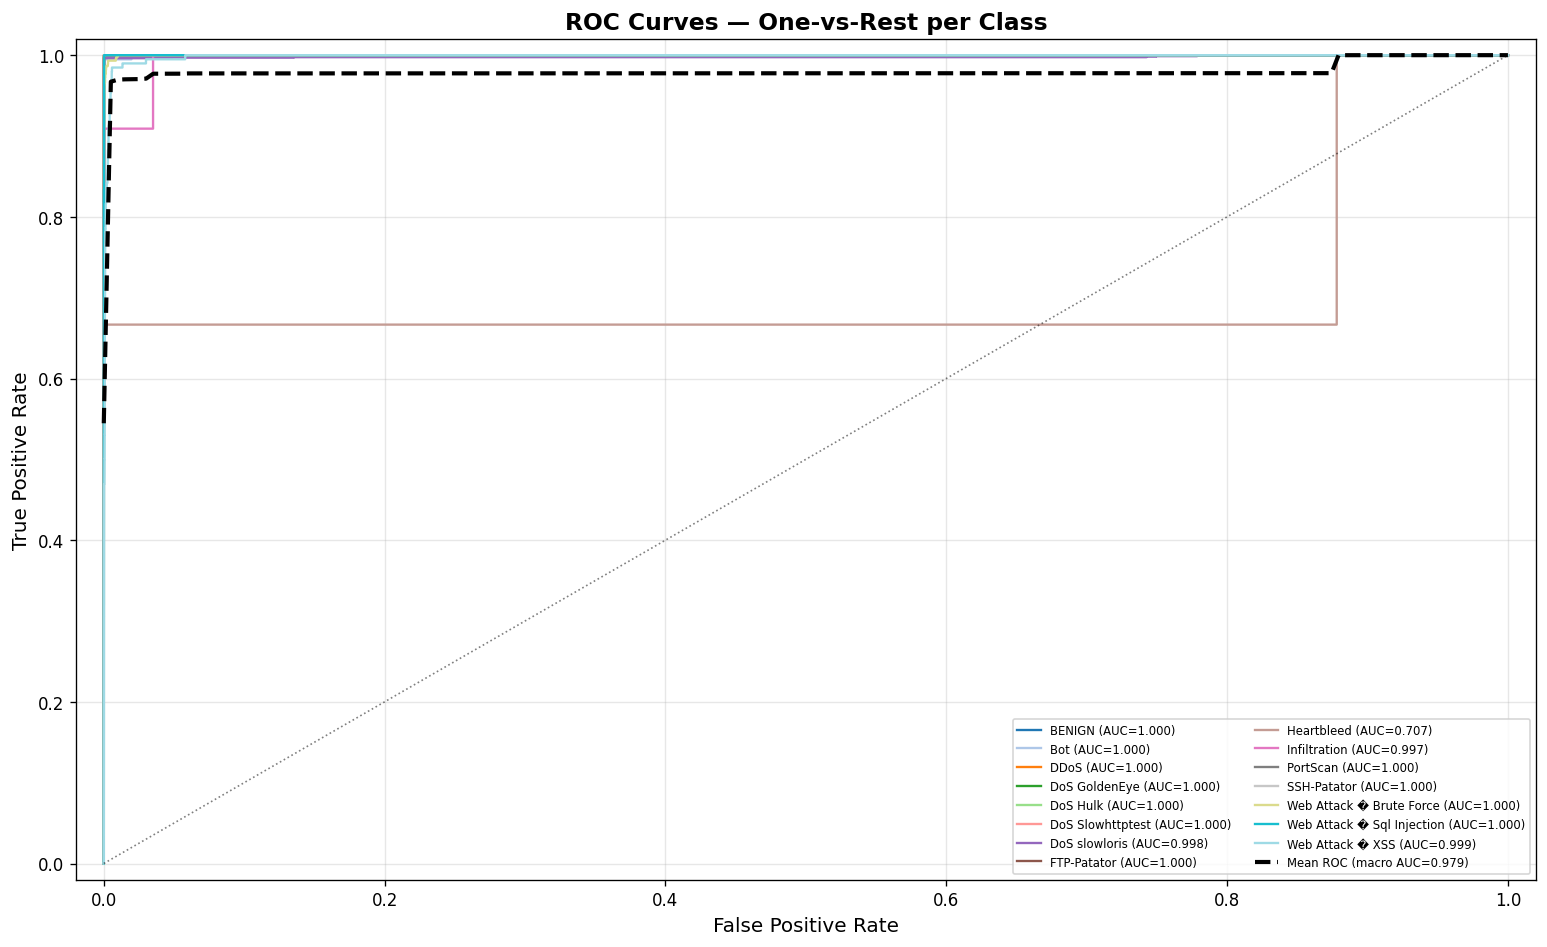

Saved: roc_curves.png


In [17]:
# ROC Curves (One-vs-Rest)
y_bin       = label_binarize(y_test, classes=list(range(n_classes)))
colors_roc  = plt.cm.tab20(np.linspace(0, 1, n_classes))

fig, ax = plt.subplots(figsize=(13, 8))
mean_fpr  = np.linspace(0, 1, 200)
tprs_mean = []

for i in range(n_classes):
    if len(np.unique(y_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc_i   = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.4, color=colors_roc[i],
            label=f'{class_names[i]} (AUC={roc_auc_i:.3f})')
    tprs_mean.append(np.interp(mean_fpr, fpr, tpr))

if tprs_mean:
    mean_tpr       = np.mean(tprs_mean, axis=0)
    mean_tpr[-1]   = 1.0
    macro_auc      = sk_auc(mean_fpr, mean_tpr)
    ax.plot(mean_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
            label=f'Mean ROC (macro AUC={macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.5)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_title('ROC Curves — One-vs-Rest per Class', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=7, ncol=2, framealpha=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

In [18]:
# Per-class AUC-ROC scores
print('\nPer-class AUC-ROC:')
for i in range(n_classes):
    if len(np.unique(y_bin[:, i])) < 2:
        print(f'  {class_names[i]:40s}: N/A (only one class in test)')
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    print(f'  {class_names[i]:40s}: {sk_auc(fpr, tpr):.4f}')


Per-class AUC-ROC:
  BENIGN                                  : 0.9998
  Bot                                     : 0.9998
  DDoS                                    : 1.0000
  DoS GoldenEye                           : 1.0000
  DoS Hulk                                : 1.0000
  DoS Slowhttptest                        : 0.9998
  DoS slowloris                           : 0.9980
  FTP-Patator                             : 0.9995
  Heartbleed                              : 0.7073
  Infiltration                            : 0.9968
  PortScan                                : 0.9998
  SSH-Patator                             : 1.0000
  Web Attack � Brute Force                : 0.9998
  Web Attack � Sql Injection              : 1.0000
  Web Attack � XSS                        : 0.9985
